
=== INFO ===
<class 'pandas.core.frame.DataFrame'>
Index: 408634 entries, 324067 to 324066
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   ID         408634 non-null  int64         
 1   Site       408634 non-null  object        
 2   Latitude   408634 non-null  float64       
 3   Longitude  408634 non-null  float64       
 4   Date       408634 non-null  object        
 5   Time       408634 non-null  object        
 6   Temp (°C)  408634 non-null  float64       
 7   Depth      408634 non-null  float64       
 8   Datetime   408634 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 31.2+ MB
None

=== MISSING VALUES ===
ID           0
Site         0
Latitude     0
Longitude    0
Date         0
Time         0
Temp (°C)    0
Depth        0
Datetime     0
dtype: int64

=== DESCRIPTION ===
count    408634.000000
mean         20.759051
std           2.980158

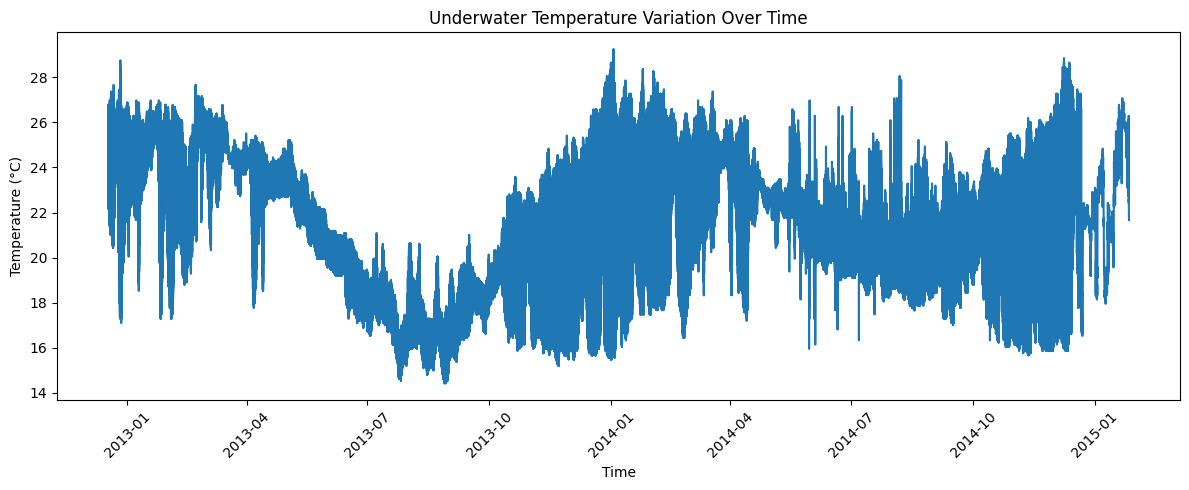

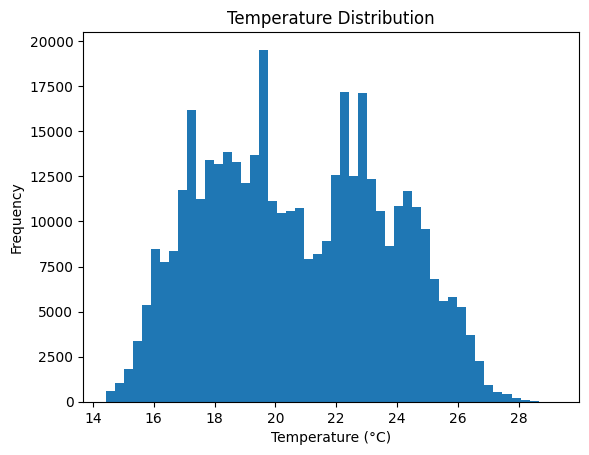

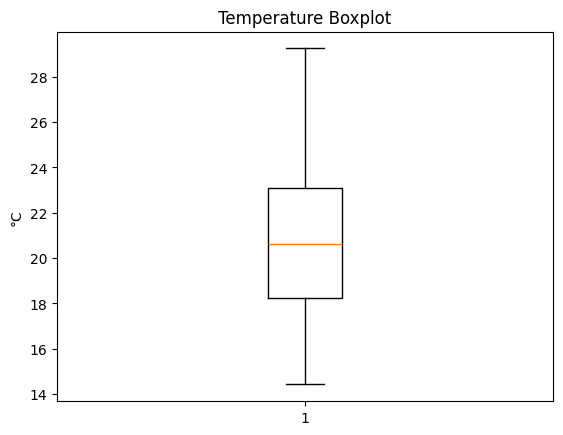

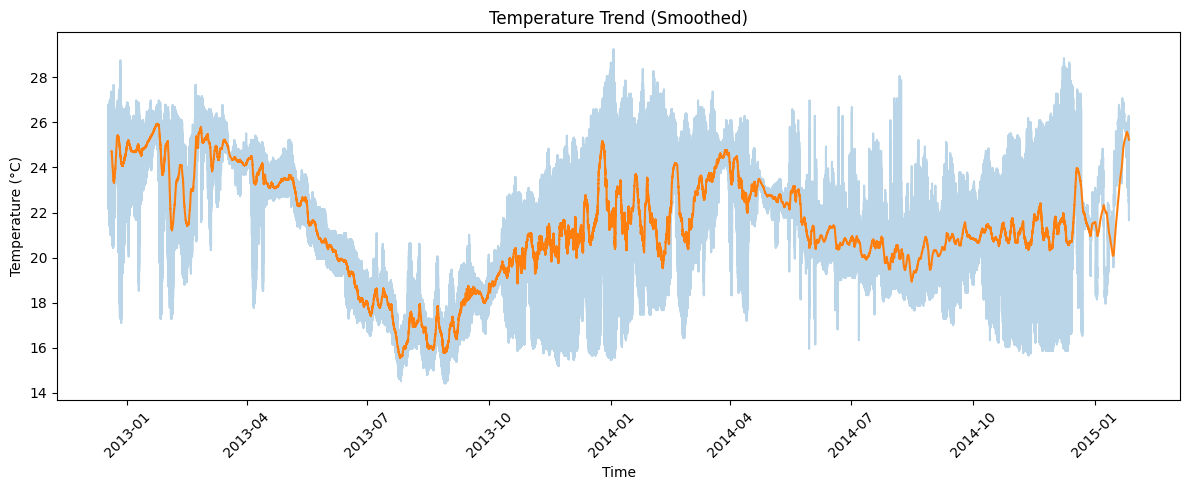

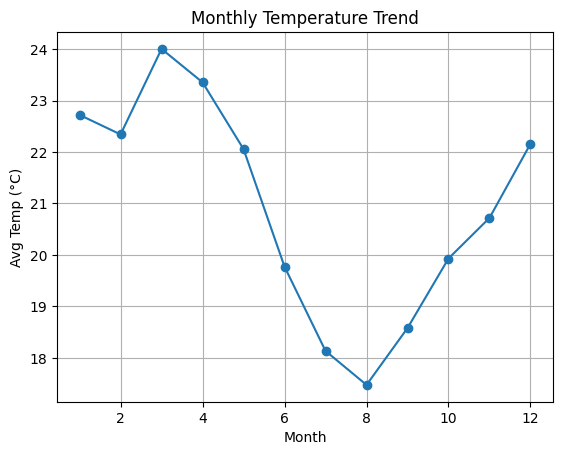

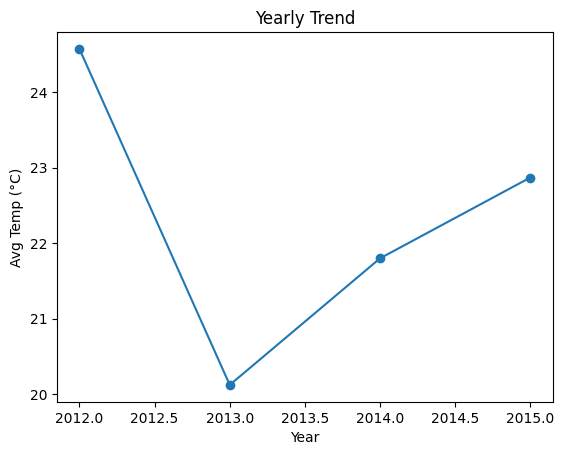

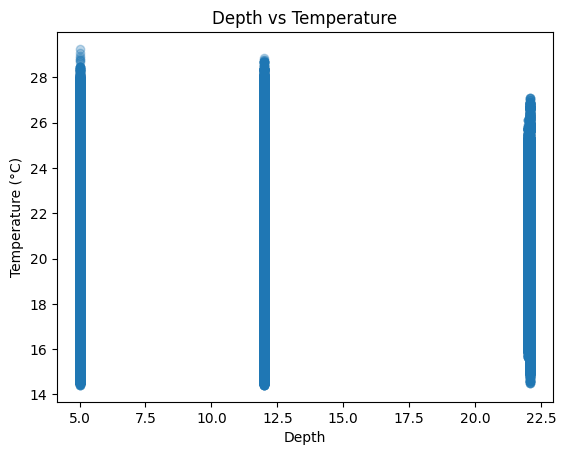


=== CORRELATION ===
           Temp (°C)     Depth
Temp (°C)   1.000000 -0.163394
Depth      -0.163394  1.000000

Number of anomalies: 3619


In [1]:
# ===============================
# 1. Import libraries
# ===============================
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# 2. Load dataset (Kaggle path)
# ===============================
file_path = "/kaggle/underwater_temperature.csv"
df = pd.read_csv(file_path, encoding='latin1')

# ===============================
# 3. Data Cleaning
# ===============================
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df.dropna(subset=['Datetime', 'Temp (°C)'])
df = df.sort_values('Datetime')

# ===============================
# 4. Basic Info (EDA)
# ===============================
print("\n=== INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DESCRIPTION ===")
print(df['Temp (°C)'].describe())

# ===============================
# 5. Line Plot (Main Requirement)
# ===============================
plt.figure(figsize=(12,5))
plt.plot(df['Datetime'], df['Temp (°C)'])

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Underwater Temperature Variation Over Time')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===============================
# 6. Histogram (Distribution)
# ===============================
plt.figure()
plt.hist(df['Temp (°C)'], bins=50)

plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Temperature Distribution')
plt.show()

# ===============================
# 7. Boxplot (Outliers)
# ===============================
plt.figure()
plt.boxplot(df['Temp (°C)'])

plt.title('Temperature Boxplot')
plt.ylabel('°C')
plt.show()

# ===============================
# 8. Rolling Mean (Trend)
# ===============================
df['Rolling_Mean'] = df['Temp (°C)'].rolling(window=500).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Datetime'], df['Temp (°C)'], alpha=0.3)
plt.plot(df['Datetime'], df['Rolling_Mean'])

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Trend (Smoothed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===============================
# 9. Monthly Analysis
# ===============================
df['Month'] = df['Datetime'].dt.month
monthly_avg = df.groupby('Month')['Temp (°C)'].mean()

plt.figure()
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')

plt.xlabel('Month')
plt.ylabel('Avg Temp (°C)')
plt.title('Monthly Temperature Trend')
plt.grid()
plt.show()

# ===============================
# 10. Yearly Trend
# ===============================
df['Year'] = df['Datetime'].dt.year
yearly_avg = df.groupby('Year')['Temp (°C)'].mean()

plt.figure()
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')

plt.xlabel('Year')
plt.ylabel('Avg Temp (°C)')
plt.title('Yearly Trend')
plt.show()

# ===============================
# 11. Depth vs Temperature
# ===============================
plt.figure()
plt.scatter(df['Depth'], df['Temp (°C)'], alpha=0.3)

plt.xlabel('Depth')
plt.ylabel('Temperature (°C)')
plt.title('Depth vs Temperature')
plt.show()

# ===============================
# 12. Correlation
# ===============================
print("\n=== CORRELATION ===")
print(df[['Temp (°C)', 'Depth']].corr())

# ===============================
# 13. Anomaly Detection
# ===============================
mean = df['Temp (°C)'].mean()
std = df['Temp (°C)'].std()

anomalies = df[(df['Temp (°C)'] > mean + 2*std) |
               (df['Temp (°C)'] < mean - 2*std)]

print("\nNumber of anomalies:", len(anomalies))